설치 확인 완료


/tmp/ipykernel_294/251208101.py:64: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(ticker, start=start, end=end, progress=False)


===== Market (S&P 500) monthly backtest =====
기간: 2001-02-28 ~ 2025-12-31
연환산 수익률(대략): 0.0671
연환산 변동성:       0.1509
샤프비율(rf=0):      0.445
MDD:                -0.526


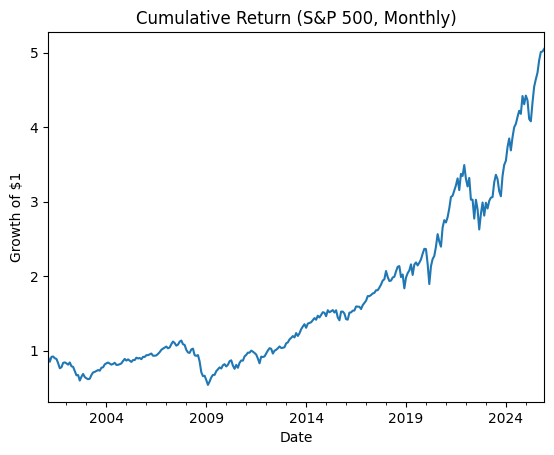

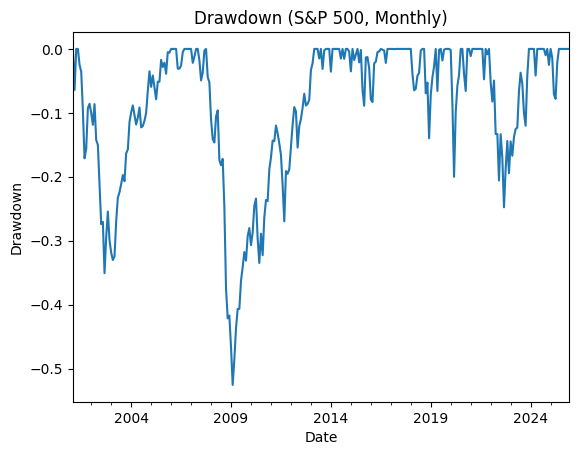

/tmp/ipykernel_294/251208101.py:125: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start=START, end=END)[0].copy()
/tmp/ipykernel_294/251208101.py:125: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start=START, end=END)[0].copy()


===== FF5 no-forecast backtest =====
기간: 2001-01-31 ~ 2025-12-31
                           AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)        0.091581  0.155232      0.589959 -0.503064
EW Factors (FF5 avg + RF)   0.049391  0.053301      0.926635 -0.123356


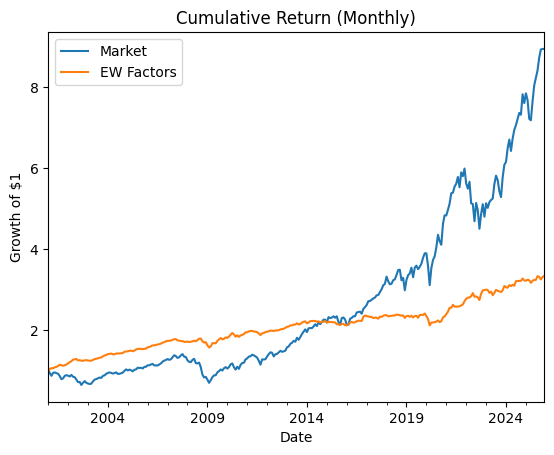

===== Rolling MV Optimization (No forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=False
                           AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)        0.110667  0.155632      0.711081 -0.503064
EW Factors                  0.039278  0.055151      0.712185 -0.123356
MV-Opt (No forecast, 60M)   0.054839  0.256202      0.214047 -0.660035


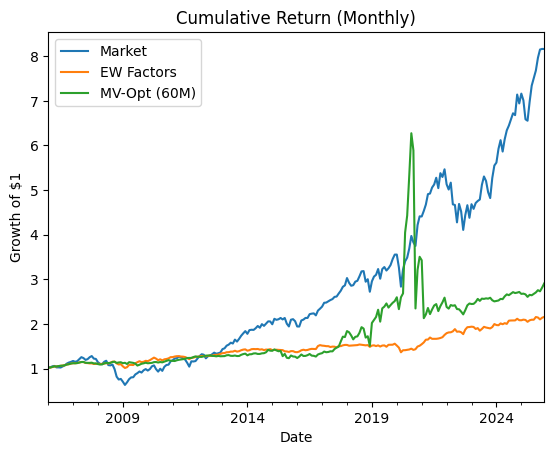

<Figure size 640x480 with 0 Axes>

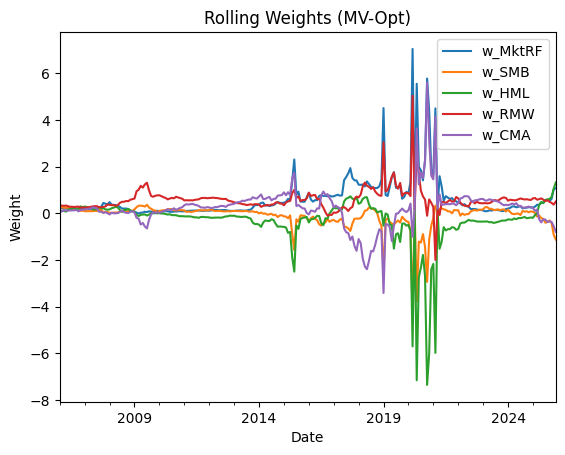


===== Rolling MV Optimization (AR1 forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=False
                            AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)         0.110667  0.155632      0.711081 -0.503064
EW Factors                   0.039278  0.055151      0.712185 -0.123356
MV-Opt (No forecast, 60M)    0.054839  0.256202      0.214047 -0.660035
MV-Opt (AR1 forecast, 60M)        NaN  1.375976           NaN -4.313743


/tmp/ipykernel_294/251208101.py:155: RuntimeWarning: invalid value encountered in scalar power
  ann_return = float((1 + r).prod() ** (12 / len(r)) - 1)


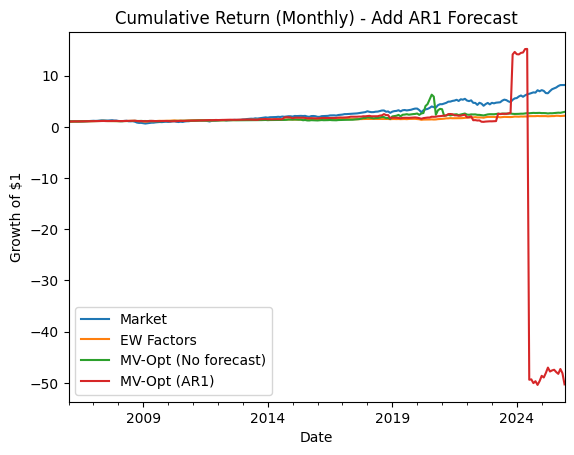

/tmp/ipykernel_294/251208101.py:155: RuntimeWarning: invalid value encountered in scalar power
  ann_return = float((1 + r).prod() ** (12 / len(r)) - 1)



===== Sprint 1 (All-in-one, Long-Short Robust) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=False
                             AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)          0.110667  0.155632      0.711081 -0.503064
EW Factors                    0.039278  0.055151      0.712185 -0.123356
MV-Opt (No forecast, 60M)     0.054839  0.256202      0.214047 -0.660035
MV-Opt (AR1 forecast, 60M)         NaN  1.375976           NaN -4.313743
MV-Opt (VAR1 forecast, 60M)   0.004186  0.192562      0.021737 -0.706930


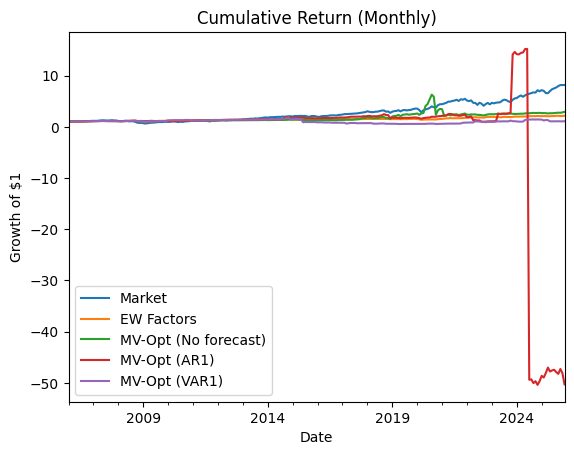

In [ ]:
# Common imports (from original scripts)
import os
import sys
import platform
from pathlib import Path
import importlib.util
import importlib.metadata as md

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

# pandas 3.x changed pandas.util._decorators.deprecate_kwarg signature; pandas_datareader expects the old one.
import inspect as _inspect
import pandas.util._decorators as _pd_decorators
if 'klass' in _inspect.signature(_pd_decorators.deprecate_kwarg).parameters:
    _new_deprecate_kwarg = _pd_decorators.deprecate_kwarg
    def _compat_deprecate_kwarg(old_arg_name, new_arg_name, mapping=None, stacklevel=2):
        return _new_deprecate_kwarg(FutureWarning, old_arg_name, new_arg_name, mapping=mapping, stacklevel=stacklevel)
    _pd_decorators.deprecate_kwarg = _compat_deprecate_kwarg


# Python 3.12+ removes stdlib distutils; pandas_datareader still imports it.
try:
    import distutils.version  # noqa: F401
except ModuleNotFoundError:
    import sys as _sys
    import setuptools._distutils as _distutils
    import setuptools._distutils.version as _distutils_version
    _distutils.version = _distutils_version
    _sys.modules['distutils'] = _distutils
    _sys.modules['distutils.version'] = _distutils_version

import pandas_datareader.data as web

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR

print("설치 확인 완료")


# =========================
# 설정
# =========================
START = "2001-01-01"
END   = "2025-12-31"

WINDOW = 60          # 60개월 rolling window
GAMMA  = 5.0         # 위험회피계수(클수록 보수적)
LONG_ONLY = False    # False로 변경: 공매도(음수 비중) 허용하여 강건성 확보

# =========================
# 1) 설정: 기간 / 종목
# =========================
start = START
end   = END
ticker = "^GSPC"   # S&P 500 지수 (야후파이낸스)

# =========================
# 2) 데이터 다운로드 (일별) -> 월말 종가로 변환
# =========================
raw = yf.download(ticker, start=start, end=end, progress=False)

# 혹시 멀티컬럼/멀티인덱스 형태로 내려와도 안전하게 'Close'만 Series로 뽑기
if isinstance(raw.columns, pd.MultiIndex):
    px = raw[("Close", ticker)]
else:
    px = raw["Close"]

px = px.dropna()

# 월말 가격 (month-end)  ※ 'M' 대신 'ME' 사용
px_m = px.resample("ME").last()

# 월별 수익률 (Series)
ret_m = px_m.pct_change().dropna()

# =========================
# 3) 누적수익률
# =========================
cum = (1 + ret_m).cumprod()

# =========================
# 4) 성과지표 (전부 float로)
# =========================
ann_return = float((1 + ret_m).prod() ** (12 / len(ret_m)) - 1)
ann_vol    = float(ret_m.std() * np.sqrt(12))
sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan

roll_max = cum.cummax()
dd = cum / roll_max - 1
mdd = float(dd.min())

# =========================
# 5) 출력
# =========================
print("===== Market (S&P 500) monthly backtest =====")
print(f"기간: {ret_m.index[0].date()} ~ {ret_m.index[-1].date()}")
print(f"연환산 수익률(대략): {ann_return:.4f}")
print(f"연환산 변동성:       {ann_vol:.4f}")
print(f"샤프비율(rf=0):      {sharpe:.3f}")
print(f"MDD:                {mdd:.3f}")

# =========================
# 6) 그래프
# =========================
plt.figure()
cum.plot()
plt.title("Cumulative Return (S&P 500, Monthly)")
plt.ylabel("Growth of $1")
plt.show()

plt.figure()
dd.plot()
plt.title("Drawdown (S&P 500, Monthly)")
plt.ylabel("Drawdown")
plt.show()

# =========================
# 1) Fama-French 5 Factors (Monthly): FF5 (2x3)
# =========================
# - FF5 (2x3): Mkt-RF, SMB, HML, RMW, CMA, RF
ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start=START, end=END)[0].copy()

# 월말 인덱스로 맞추기
ff5.index = pd.to_datetime(ff5.index.astype(str)) + pd.offsets.MonthEnd(0)

# % -> 소수로 변환
ff5 = ff5 / 100.0

# 기간 자르기
ff = ff5.loc[(ff5.index >= START) & (ff5.index <= END)].dropna()

# 사용할 팩터 (초과수익 팩터 5개)
F = ff[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].copy()   # excess returns
RF = ff["RF"].copy()  # risk-free

# 인덱스 지정 (에러 삭제용)
F = F.asfreq('ME')
RF = RF.asfreq('ME')

# =========================
# 2) "no forecast" 고정 비중 포트폴리오 (비교용)
# =========================
ret_mkt = ff["Mkt-RF"] + ff["RF"]
ret_ew = F.mean(axis=1) + ff["RF"]

# =========================
# 3) 성과지표 함수
# =========================
def perf_stats(r: pd.Series, name: str):
    r = r.dropna()
    ann_return = float((1 + r).prod() ** (12 / len(r)) - 1)
    ann_vol    = float(r.std() * np.sqrt(12))
    sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = float(dd.min())

    return pd.Series({"AnnReturn": ann_return, "AnnVol": ann_vol, "Sharpe(rf=0)": sharpe, "MDD": mdd}, name=name)

stats = pd.concat([
    perf_stats(ret_mkt, "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew,  "EW Factors (FF5 avg + RF)"),
], axis=1)

print("===== FF5 no-forecast backtest =====")
print(f"기간: {ff.index[0].date()} ~ {ff.index[-1].date()}")
print(stats.T)

# =========================
# 4) 그래프
# =========================
cum_mkt = (1 + ret_mkt).cumprod()
cum_ew  = (1 + ret_ew).cumprod()

plt.figure()
cum_mkt.plot(label="Market")
cum_ew.plot(label="EW Factors")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# =========================
# 3) 평균-분산 최적화 함수 (long-short 강건성 강화)
#    w* = (1/gamma) * Sigma^{-1} * mu
#    (초과수익 기준; 총수익은 RF + w·F)
# =========================
def mv_weights(mu: np.ndarray, cov: np.ndarray, gamma: float, long_only: bool) -> np.ndarray:
    # 수치 안정화: 공분산 행렬에 작은 값 더하기
    eps = 1e-6
    cov = cov + eps * np.eye(cov.shape[0])

    w = (1.0 / gamma) * np.linalg.solve(cov, mu)  # Sigma^{-1} mu

    if long_only:
        w = np.maximum(w, 0.0)  # 음수 제거 (long-only)

    # 너무 크거나 이상한 값 방지: 합이 0이면 균등
    s = w.sum()
    if s <= 1e-12:
        w = np.ones_like(w) / len(w)
    else:
        # "팩터 포트폴리오"를 100%로 정규화(합=1, net exposure=1)
        w = w / s

    # 강건성 확보: long-short 시 gross exposure 제한 (sum(abs(w)) <= 2.0)
    # 과도한 short 노출 방지 (거래 비용/리스크 고려)
    if not long_only:
        gross = np.sum(np.abs(w))
        if gross > 2.0:
            w = w / gross * 2.0  # 스케일 다운: long 비중 ↑, short 비중 ↓ 조정
            # net exposure 재정규화 (합=1 유지)
            w = w / w.sum()

    return w

# =========================
# 4) Rolling backtest
# =========================
dates = F.index
rets_opt = []
w_hist = []

for t in range(WINDOW, len(dates)):
    # 추정 구간: t-WINDOW ~ t-1
    train = F.iloc[t-WINDOW:t]
    mu = train.mean().values                # (5,)  # FF5 팩터 5개
    cov = train.cov().values                # (5,5)

    w = mv_weights(mu, cov, gamma=GAMMA, long_only=LONG_ONLY)
    w_hist.append(w)

    # 투자 구간: t (다음 달) 실현 수익률
    f_next = F.iloc[t].values               # (5,)
    r_next = float(RF.iloc[t] + np.dot(w, f_next))  # 총수익 = RF + w·(excess factors)
    rets_opt.append(r_next)

ret_opt = pd.Series(rets_opt, index=dates[WINDOW:], name="MV-Opt (No forecast, 60M)")

w_hist = pd.DataFrame(w_hist, index=dates[WINDOW:], columns=["w_" + ''.join(ch for ch in c if ch.isalnum()) for c in F.columns])
# =========================
# 5) 성과지표
# =========================
stats3 = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)")
], axis=1).T

print("===== Rolling MV Optimization (No forecast) =====")
print(f"기간(최적화 백테스트): {ret_opt.index[0].date()} ~ {ret_opt.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}")
print(stats3)

# =========================
# 6) 그래프: 누적수익률 + 가중치 변화
# =========================
cum_mkt_roll = (1 + ret_mkt.loc[ret_opt.index]).cumprod()
cum_ew_roll  = (1 + ret_ew.loc[ret_opt.index]).cumprod()
cum_opt = (1 + ret_opt).cumprod()

plt.figure()
cum_mkt_roll.plot(label="Market")
cum_ew_roll.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (60M)")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

plt.figure()
w_hist.plot()
plt.title("Rolling Weights (MV-Opt)")
plt.ylabel("Weight")
plt.show()

# =========================
# AR(1)로 다음 달 팩터 프리미엄(초과수익) 예측해서 mu 만들기
# mu_hat = [E(Mkt-RF_{t+1}), E(SMB_{t+1}), E(HML_{t+1}), E(RMW_{t+1}), E(CMA_{t+1})]
# =========================
def ar1_forecast_mu(train_df: pd.DataFrame) -> np.ndarray:
    mu_hat = []
    for col in train_df.columns:
        y = train_df[col].values

        # AR(1) 적합 (상수 포함)
        model = AutoReg(y, lags=1, trend="c", old_names=False).fit()

        # 1-step ahead forecast
        f = float(model.forecast(steps=1)[0])
        mu_hat.append(f)

    return np.array(mu_hat)

# =========================
# AR Forecast + MV Optimization Rolling Backtest
# =========================
rets_ar = []
w_ar_hist = []

for t in range(WINDOW, len(dates)):
    train = F.iloc[t-WINDOW:t]

    # 기대수익(μ)을 AR(1) 예측값으로 사용
    mu_hat = ar1_forecast_mu(train)

    # 공분산은 과거 60개월 샘플 공분산
    cov = train.cov().values

    w = mv_weights(mu_hat, cov, gamma=GAMMA, long_only=LONG_ONLY)
    w_ar_hist.append(w)

    f_next = F.iloc[t].values
    r_next = float(RF.iloc[t] + np.dot(w, f_next))
    rets_ar.append(r_next)

ret_ar = pd.Series(rets_ar, index=dates[WINDOW:], name="MV-Opt (AR1 forecast, 60M)")
w_ar_hist = pd.DataFrame(w_ar_hist, index=dates[WINDOW:], columns=["w_" + ''.join(ch for ch in c if ch.isalnum()) for c in F.columns])
# =========================
# 비교표 업데이트 (Market / EW / No-forecast MV / AR MV)
# =========================
stats4 = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)"),
    perf_stats(ret_ar,                    "MV-Opt (AR1 forecast, 60M)")
], axis=1).T

print("\n===== Rolling MV Optimization (AR1 forecast) =====")
print(f"기간(최적화 백테스트): {ret_ar.index[0].date()} ~ {ret_ar.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}")
print(stats4)

# =========================
# 누적수익률 비교 그래프 (옵션)
# =========================
cum_ar = (1 + ret_ar).cumprod()

plt.figure()
cum_mkt_roll.plot(label="Market")
cum_ew_roll.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (No forecast)")
cum_ar.plot(label="MV-Opt (AR1)")
plt.title("Cumulative Return (Monthly) - Add AR1 Forecast")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# =========================
# VAR(1) forecast (joint)
# =========================
def var1_forecast_mu(train_df: pd.DataFrame) -> np.ndarray:
    model = VAR(train_df)
    results = model.fit(1)  # VAR(1)
    fcast = results.forecast(train_df.values[-1:], steps=1)
    return fcast[0]         # shape (5,)

rets_var = []
w_var_hist = []

for t in range(WINDOW, len(dates)):
    train = F.iloc[t-WINDOW:t]
    mu_hat = var1_forecast_mu(train)
    cov = train.cov().values

    w = mv_weights(mu_hat, cov, gamma=GAMMA, long_only=LONG_ONLY)
    w_var_hist.append(w)

    f_next = F.iloc[t].values
    r_next = float(RF.iloc[t] + np.dot(w, f_next))
    rets_var.append(r_next)

ret_var = pd.Series(rets_var, index=dates[WINDOW:], name="MV-Opt (VAR1 forecast, 60M)")
w_var_hist = pd.DataFrame(w_var_hist, index=dates[WINDOW:], columns=["w_" + ''.join(ch for ch in c if ch.isalnum()) for c in F.columns])
# =========================
# Compare stats (aligned to rolling period)
# =========================
idx = ret_opt.index  # rolling period starts here

stats5 = pd.concat([
    perf_stats(ret_mkt.loc[idx], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[idx],  "EW Factors"),
    perf_stats(ret_opt,          "MV-Opt (No forecast, 60M)"),
    perf_stats(ret_ar,           "MV-Opt (AR1 forecast, 60M)"),
    perf_stats(ret_var,          "MV-Opt (VAR1 forecast, 60M)")
], axis=1).T

print("\n===== Sprint 1 (All-in-one, Long-Short Robust) =====")
print(f"기간(최적화 백테스트): {idx[0].date()} ~ {idx[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}")
print(stats5)

# =========================
# Plots
# =========================
cum_var = (1 + ret_var).cumprod()

plt.figure()
cum_mkt_roll.plot(label="Market")
cum_ew_roll.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (No forecast)")
cum_ar.plot(label="MV-Opt (AR1)")
cum_var.plot(label="MV-Opt (VAR1)")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# plt.figure()
# w_hist.plot()
# plt.title("Weights - MV (No forecast)")
# plt.ylabel("Weight")
# plt.show()

# plt.figure()
# w_ar_hist.plot()
# plt.title("Weights - MV (AR1)")
# plt.ylabel("Weight")
# plt.show()

# plt.figure()
# w_var_hist.plot()
# plt.title("Weights - MV (VAR1)")
# plt.ylabel("Weight")
# plt.show()



설치 확인 완료
===== Market (S&P 500) monthly backtest =====
기간: 2001-02-28 ~ 2025-12-31
연환산 수익률(대략): 0.0671
연환산 변동성:       0.1509
샤프비율(rf=0):      0.445
MDD:                -0.526


/tmp/ipykernel_294/1590322612.py:71: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(ticker, start=start, end=end, progress=False)


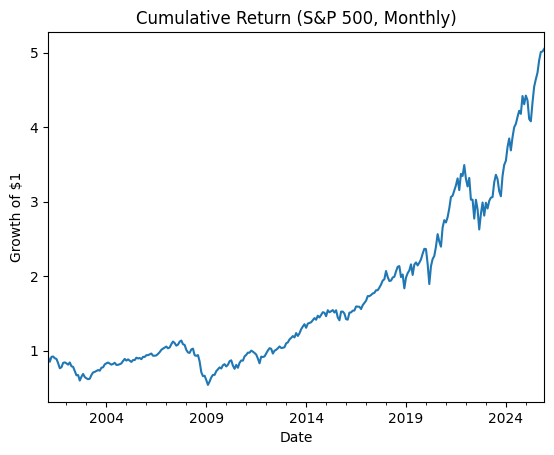

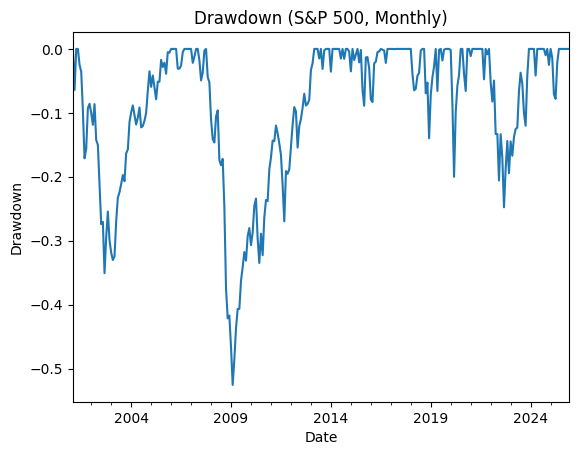

/tmp/ipykernel_294/1590322612.py:132: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start=START, end=END)[0].copy()
/tmp/ipykernel_294/1590322612.py:132: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start=START, end=END)[0].copy()


===== FF5 no-forecast backtest =====
기간: 2001-01-31 ~ 2025-12-31
                           AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)        0.091581  0.155232      0.589959 -0.503064
EW Factors (FF5 avg + RF)   0.049391  0.053301      0.926635 -0.123356


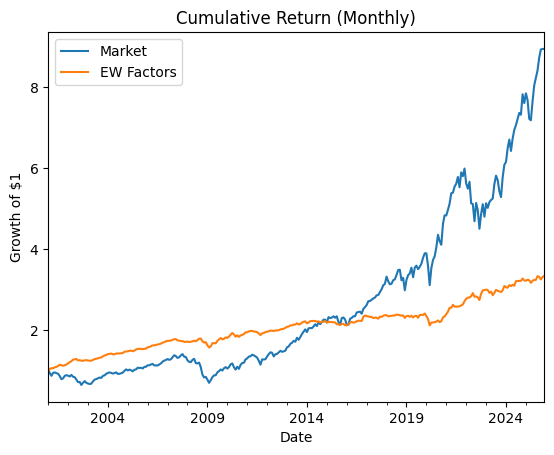

===== Rolling MV Optimization (No forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=True, GROSS_TARGET=1.0
                           AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)        0.110667  0.155632      0.711081 -0.503064
EW Factors                  0.039278  0.055151      0.712185 -0.123356
MV-Opt (No forecast, 60M)   0.051169  0.060364      0.847672 -0.135614


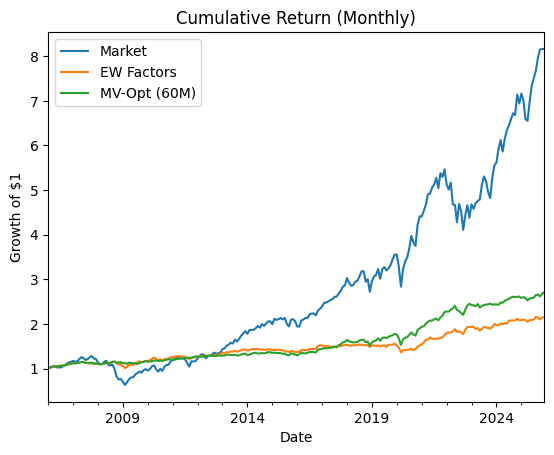

<Figure size 640x480 with 0 Axes>

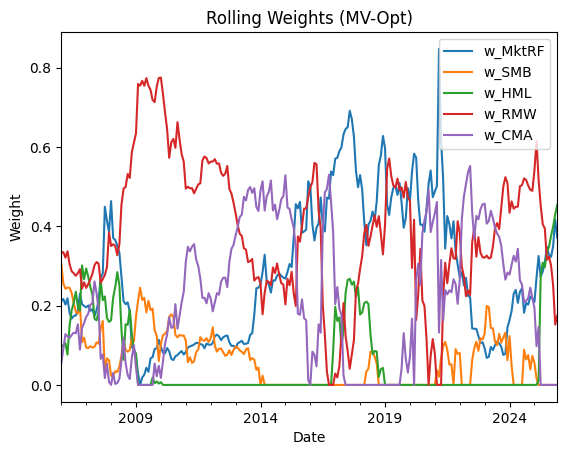


===== Rolling MV Optimization (AR1 forecast) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=True, GROSS_TARGET=1.0
                            AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)         0.110667  0.155632      0.711081 -0.503064
EW Factors                   0.039278  0.055151      0.712185 -0.123356
MV-Opt (No forecast, 60M)    0.051169  0.060364      0.847672 -0.135614
MV-Opt (AR1 forecast, 60M)   0.058960  0.065612      0.898621 -0.101537


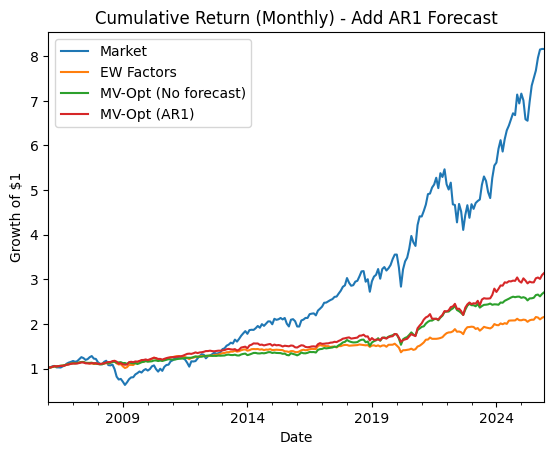


===== Sprint 1 (All-in-one) =====
기간(최적화 백테스트): 2006-01-31 ~ 2025-12-31
WINDOW=60, GAMMA=5.0, LONG_ONLY=True, GROSS_TARGET=1.0
                             AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)          0.110667  0.155632      0.711081 -0.503064
EW Factors                    0.039278  0.055151      0.712185 -0.123356
MV-Opt (No forecast, 60M)     0.051169  0.060364      0.847672 -0.135614
MV-Opt (AR1 forecast, 60M)    0.058960  0.065612      0.898621 -0.101537
MV-Opt (VAR1 forecast, 60M)   0.023738  0.061404      0.386584 -0.146100


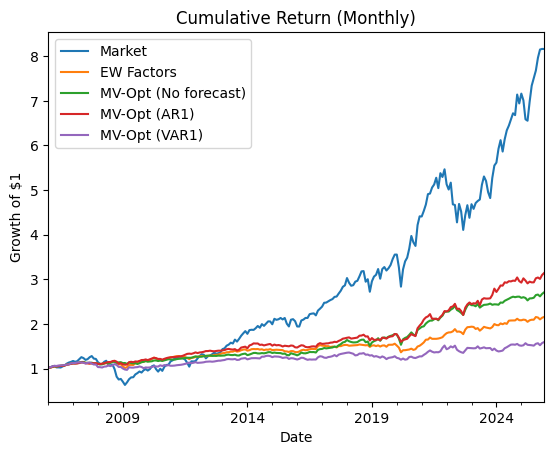


===== Robustness A - Full =====
기간: 2006-01-31 ~ 2025-12-31 (N=240개월)
                             AnnReturn    AnnVol  Sharpe(rf=0)       MDD  \
Market (Mkt-RF + RF)          0.110667  0.155632      0.711081 -0.503064   
EW Factors                    0.039278  0.055151      0.712185 -0.123356   
MV-Opt (No forecast, 60M)     0.051169  0.060364      0.847672 -0.135614   
MV-Opt (AR1 forecast, 60M)    0.058960  0.065612      0.898621 -0.101537   
MV-Opt (VAR1 forecast, 60M)   0.023738  0.061404      0.386584 -0.146100   

                             NMonths  
Market (Mkt-RF + RF)           240.0  
EW Factors                     240.0  
MV-Opt (No forecast, 60M)      240.0  
MV-Opt (AR1 forecast, 60M)     240.0  
MV-Opt (VAR1 forecast, 60M)    240.0  

===== Robustness A - First half =====
기간: 2006-01-31 ~ 2015-12-31 (N=120개월)
                             AnnReturn    AnnVol  Sharpe(rf=0)       MDD  \
Market (Mkt-RF + RF)          0.075228  0.153967      0.488597 -0.503064   
EW Factor

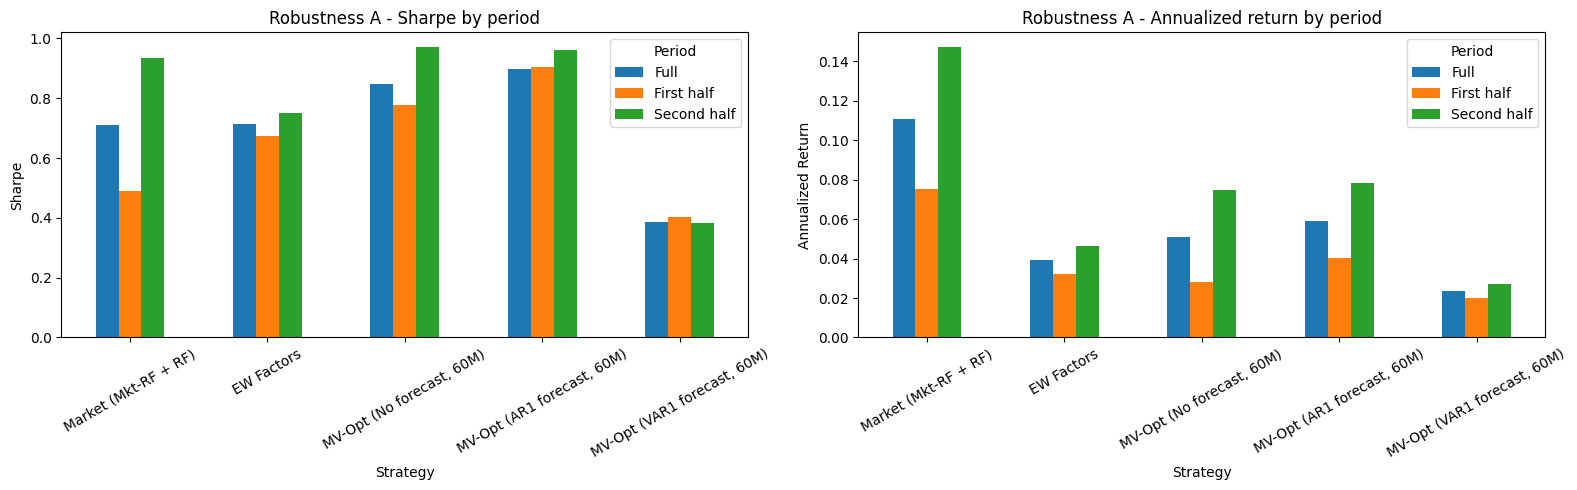


===== Robustness B1 - NBER recession months =====
기간: 2007-12-31 ~ 2020-04-30 (N=22개월)
                             AnnReturn    AnnVol  Sharpe(rf=0)       MDD  \
Market (Mkt-RF + RF)         -0.244313  0.272739     -0.895776 -0.476727   
EW Factors                   -0.049791  0.093606     -0.531918 -0.158871   
MV-Opt (No forecast, 60M)    -0.032720  0.104595     -0.312830 -0.158692   
MV-Opt (AR1 forecast, 60M)   -0.029828  0.080071     -0.372513 -0.119263   
MV-Opt (VAR1 forecast, 60M)  -0.042044  0.085557     -0.491418 -0.116281   

                             NMonths  
Market (Mkt-RF + RF)            22.0  
EW Factors                      22.0  
MV-Opt (No forecast, 60M)       22.0  
MV-Opt (AR1 forecast, 60M)      22.0  
MV-Opt (VAR1 forecast, 60M)     22.0  

===== Robustness B2 - Non-recession months =====
기간: 2006-01-31 ~ 2025-12-31 (N=218개월)
                             AnnReturn    AnnVol  Sharpe(rf=0)       MDD  \
Market (Mkt-RF + RF)          0.154679  0.135220      1.1

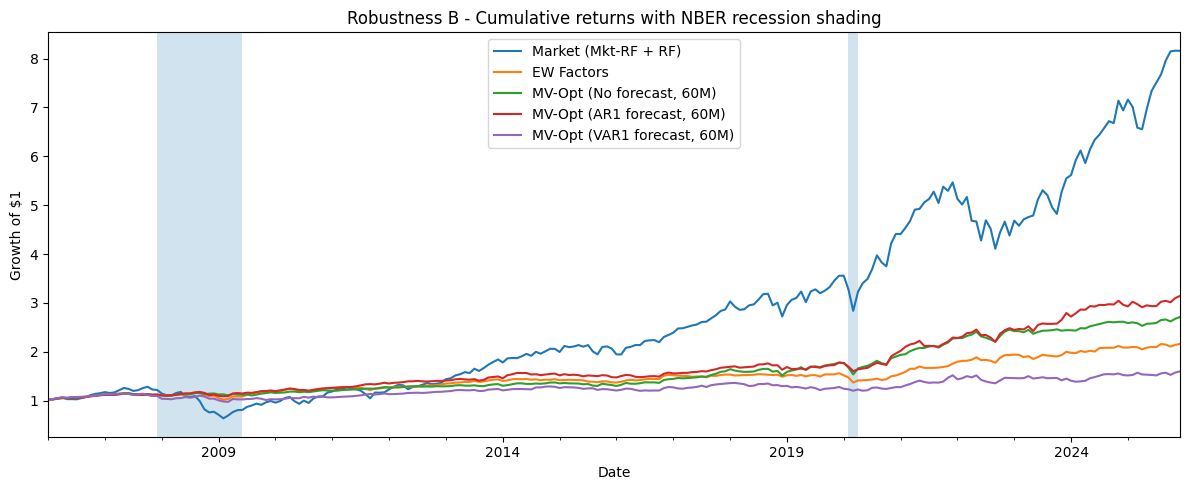

<Figure size 1000x500 with 0 Axes>

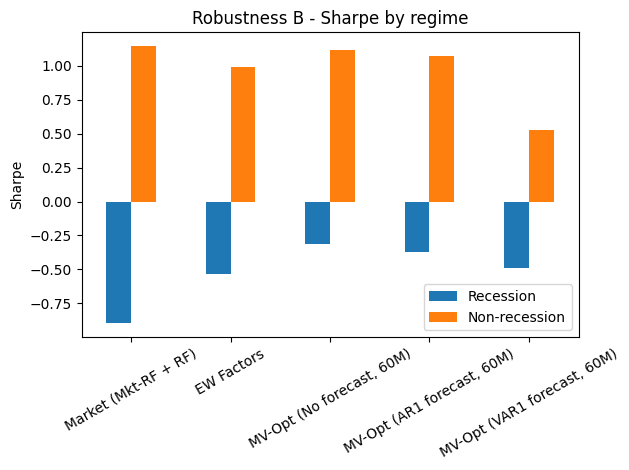


Robustness C - No forecast
공통구간: 2011-01-31 ~ 2025-12-31
                            AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)         0.138485  0.145972      0.948706 -0.248294
EW Factors                   0.036620  0.053887      0.679581 -0.122887
MV-Opt (No forecast, 36M)    0.049718  0.063140      0.787413 -0.101058
MV-Opt (No forecast, 60M)    0.055413  0.066013      0.839424 -0.135614
MV-Opt (No forecast, 120M)   0.052883  0.055783      0.948021 -0.103089

Robustness C - AR1 forecast
공통구간: 2011-01-31 ~ 2025-12-31
                             AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (Mkt-RF + RF)          0.138485  0.145972      0.948706 -0.248294
EW Factors                    0.036620  0.053887      0.679581 -0.122887
MV-Opt (AR1 forecast, 36M)    0.053127  0.070871      0.749631 -0.144739
MV-Opt (AR1 forecast, 60M)    0.063165  0.071084      0.888589 -0.101537
MV-Opt (AR1 forecast, 120M)   0.059992  0.069939      0.857776 -0.119650

Robustness C

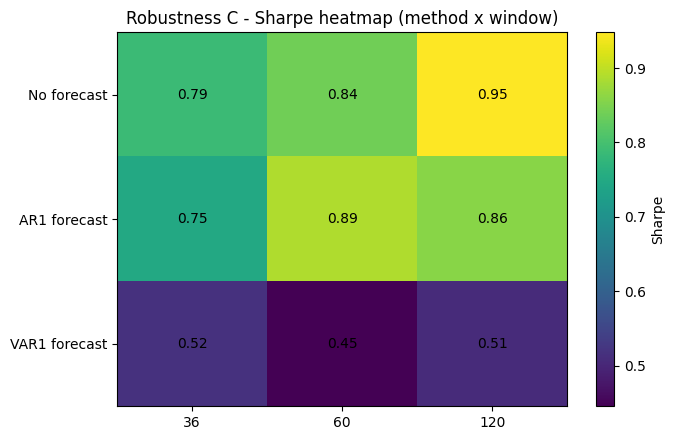

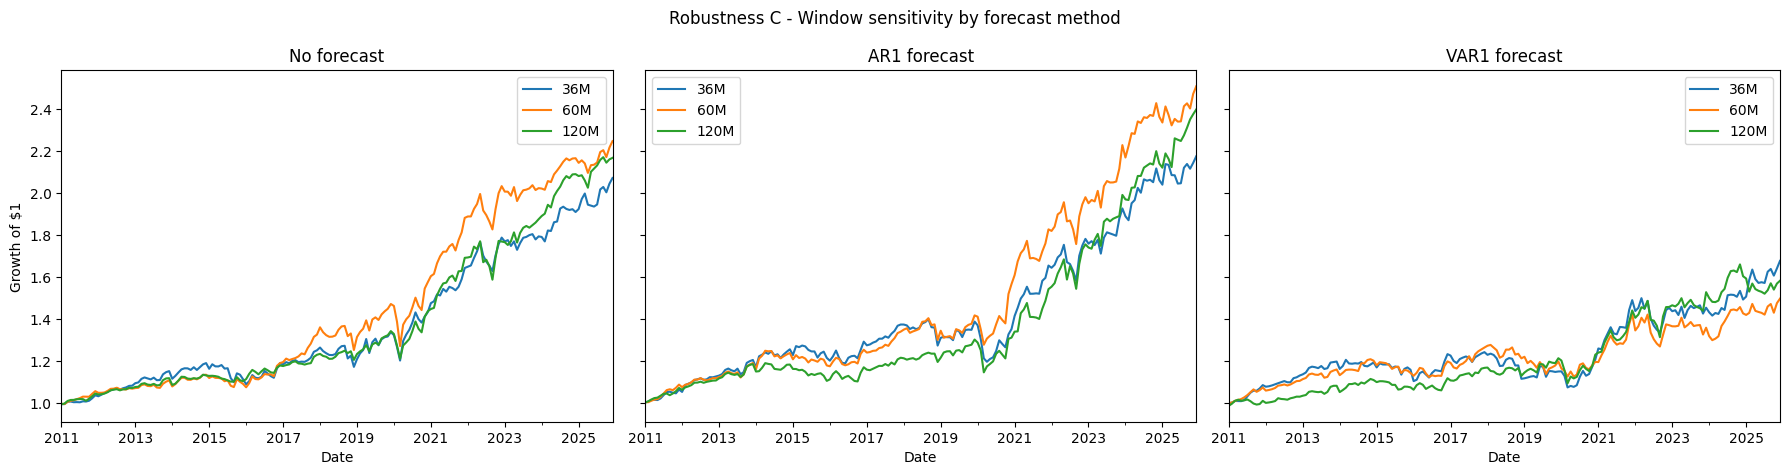


Robustness D - Long-only (LO) vs Long-short (LS)
LS gross exposure target: 1.0

[LO] Performance
                         AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (LO)               0.110667  0.155632      0.711081 -0.503064
EW Factors (LO)           0.039278  0.055151      0.712185 -0.123356
MV-Opt No forecast (LO)   0.051169  0.060364      0.847672 -0.135614
MV-Opt AR1 (LO)           0.058960  0.065612      0.898621 -0.101537
MV-Opt VAR1 (LO)          0.023738  0.061404      0.386584 -0.146100

[LS] Performance
                         AnnReturn    AnnVol  Sharpe(rf=0)       MDD
Market (LS)               0.110667  0.155632      0.711081 -0.503064
EW Factors (LS)           0.039278  0.055151      0.712185 -0.123356
MV-Opt No forecast (LS)   0.038014  0.042148      0.901921 -0.073626
MV-Opt AR1 (LS)           0.042078  0.041568      1.012267 -0.065620
MV-Opt VAR1 (LS)          0.020458  0.043554      0.469718 -0.095047

Weights stability summary (gross/net/short fraction)

[

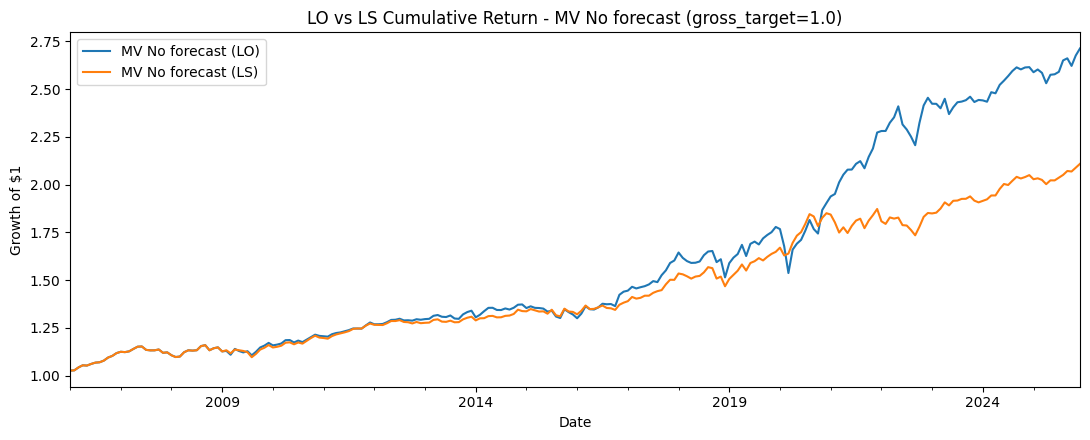

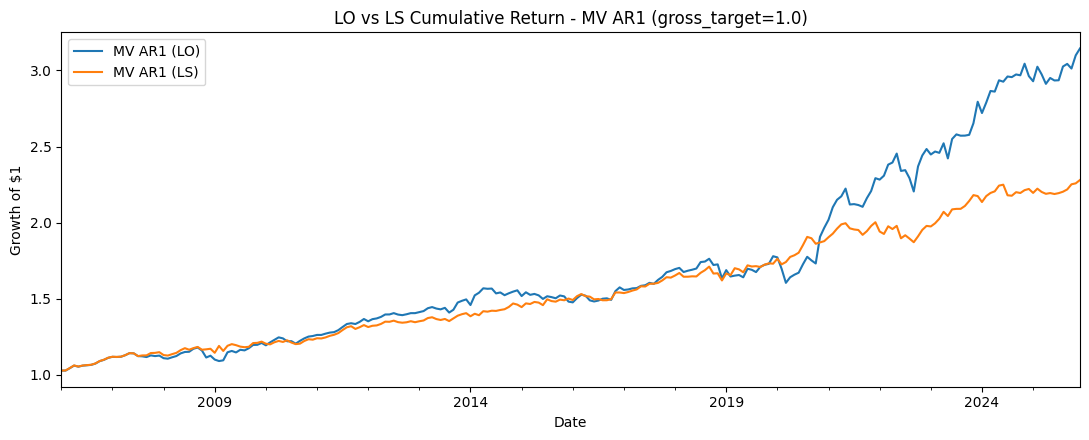

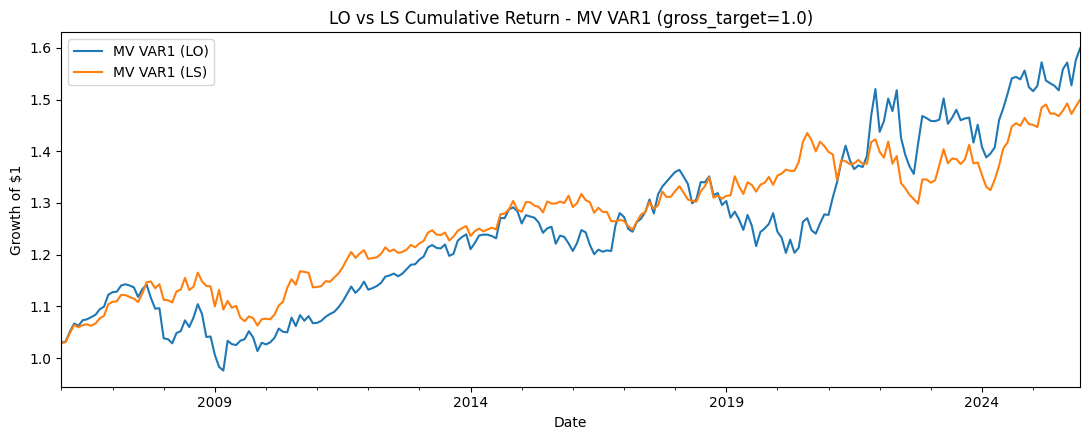

<Figure size 1100x450 with 0 Axes>

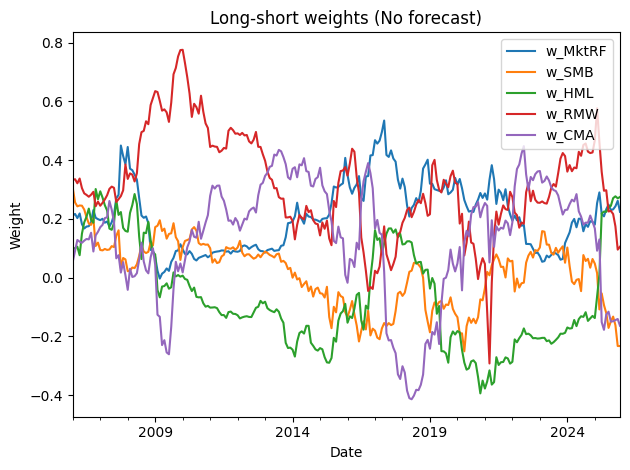

<Figure size 1100x450 with 0 Axes>

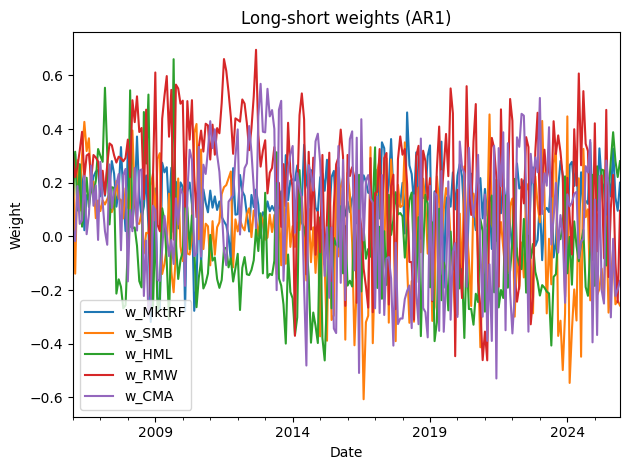

<Figure size 1100x450 with 0 Axes>

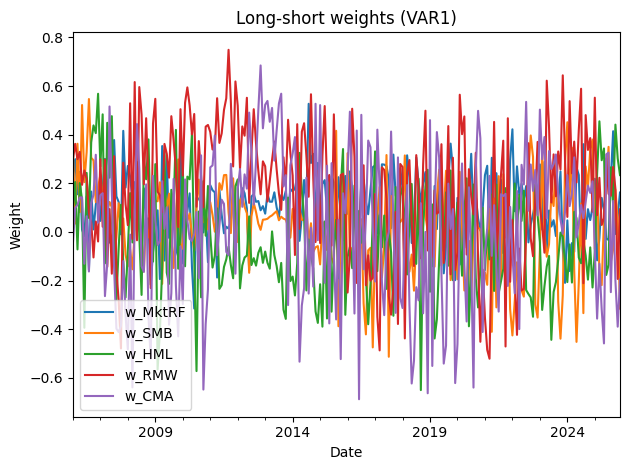

In [ ]:
# =========================================================
# FULL SCRIPT (Long-only vs Long-short robustness included)
# - Your original pipeline + long-short (LONG_ONLY=False) robustness check
# - Key fix: long-short should NOT force sum(w)=1; use gross exposure scaling
# =========================================================

# -------------------------
# Common imports (from original scripts)
# -------------------------
import os
import sys
import platform
from pathlib import Path
import importlib.util
import importlib.metadata as md

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

# pandas 3.x changed pandas.util._decorators.deprecate_kwarg signature; pandas_datareader expects the old one.
import inspect as _inspect
import pandas.util._decorators as _pd_decorators
if 'klass' in _inspect.signature(_pd_decorators.deprecate_kwarg).parameters:
    _new_deprecate_kwarg = _pd_decorators.deprecate_kwarg
    def _compat_deprecate_kwarg(old_arg_name, new_arg_name, mapping=None, stacklevel=2):
        return _new_deprecate_kwarg(FutureWarning, old_arg_name, new_arg_name, mapping=mapping, stacklevel=stacklevel)
    _pd_decorators.deprecate_kwarg = _compat_deprecate_kwarg

# Python 3.12+ removes stdlib distutils; pandas_datareader still imports it.
try:
    import distutils.version  # noqa: F401
except ModuleNotFoundError:
    import sys as _sys
    import setuptools._distutils as _distutils
    import setuptools._distutils.version as _distutils_version
    _distutils.version = _distutils_version
    _sys.modules['distutils'] = _distutils
    _sys.modules['distutils.version'] = _distutils_version

import pandas_datareader.data as web

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR

print("설치 확인 완료")

# =========================
# 설정
# =========================
START = "2001-01-01"
END   = "2025-12-31"

WINDOW = 60          # 60개월 rolling window
GAMMA  = 5.0         # 위험회피계수(클수록 보수적)
LONG_ONLY = True     # True면 공매도(음수 비중) 금지 (baseline)
GROSS_TARGET = 1.0   # long-short일 때 sum(|w|)=GROSS_TARGET로 제한

# =========================
# 1) 설정: 기간 / 종목
# =========================
start = START
end   = END
ticker = "^GSPC"   # S&P 500 지수 (야후파이낸스)

# =========================
# 2) 데이터 다운로드 (일별) -> 월말 종가로 변환
# =========================
raw = yf.download(ticker, start=start, end=end, progress=False)

# 혹시 멀티컬럼/멀티인덱스 형태로 내려와도 안전하게 'Close'만 Series로 뽑기
if isinstance(raw.columns, pd.MultiIndex):
    px = raw[("Close", ticker)]
else:
    px = raw["Close"]

px = px.dropna()

# 월말 가격 (month-end)  ※ 'M' 대신 'ME' 사용
px_m = px.resample("ME").last()

# 월별 수익률 (Series)
ret_m = px_m.pct_change().dropna()

# =========================
# 3) 누적수익률
# =========================
cum = (1 + ret_m).cumprod()

# =========================
# 4) 성과지표 (전부 float로)
# =========================
ann_return = float((1 + ret_m).prod() ** (12 / len(ret_m)) - 1)
ann_vol    = float(ret_m.std() * np.sqrt(12))
sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan

roll_max = cum.cummax()
dd = cum / roll_max - 1
mdd = float(dd.min())

# =========================
# 5) 출력
# =========================
print("===== Market (S&P 500) monthly backtest =====")
print(f"기간: {ret_m.index[0].date()} ~ {ret_m.index[-1].date()}")
print(f"연환산 수익률(대략): {ann_return:.4f}")
print(f"연환산 변동성:       {ann_vol:.4f}")
print(f"샤프비율(rf=0):      {sharpe:.3f}")
print(f"MDD:                {mdd:.3f}")

# =========================
# 6) 그래프
# =========================
plt.figure()
cum.plot()
plt.title("Cumulative Return (S&P 500, Monthly)")
plt.ylabel("Growth of $1")
plt.show()

plt.figure()
dd.plot()
plt.title("Drawdown (S&P 500, Monthly)")
plt.ylabel("Drawdown")
plt.show()

# =========================
# 1) Fama-French 5 Factors (Monthly): FF5 (2x3)
# =========================
# - FF5 (2x3): Mkt-RF, SMB, HML, RMW, CMA, RF
ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start=START, end=END)[0].copy()

# 월말 인덱스로 맞추기
ff5.index = pd.to_datetime(ff5.index.astype(str)) + pd.offsets.MonthEnd(0)

# % -> 소수로 변환
ff5 = ff5 / 100.0

# 기간 자르기
ff = ff5.loc[(ff5.index >= START) & (ff5.index <= END)].dropna()

# 사용할 팩터 (초과수익 팩터 5개)
F = ff[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].copy()   # excess returns
RF = ff["RF"].copy()  # risk-free

# 인덱스 지정 (에러 삭제용)
F = F.asfreq('ME')
RF = RF.asfreq('ME')

# =========================
# 2) "no forecast" 고정 비중 포트폴리오 (비교용)
# =========================
ret_mkt = ff["Mkt-RF"] + ff["RF"]
ret_ew = F.mean(axis=1) + ff["RF"]

# =========================
# 3) 성과지표 함수
# =========================
def perf_stats(r: pd.Series, name: str):
    r = r.dropna()
    ann_return = float((1 + r).prod() ** (12 / len(r)) - 1)
    ann_vol    = float(r.std() * np.sqrt(12))
    sharpe     = ann_return / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = float(dd.min())

    return pd.Series({"AnnReturn": ann_return, "AnnVol": ann_vol, "Sharpe(rf=0)": sharpe, "MDD": mdd}, name=name)

stats = pd.concat([
    perf_stats(ret_mkt, "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew,  "EW Factors (FF5 avg + RF)"),
], axis=1)

print("===== FF5 no-forecast backtest =====")
print(f"기간: {ff.index[0].date()} ~ {ff.index[-1].date()}")
print(stats.T)

# =========================
# 4) 그래프
# =========================
cum_mkt = (1 + ret_mkt).cumprod()
cum_ew  = (1 + ret_ew).cumprod()

plt.figure()
cum_mkt.plot(label="Market")
cum_ew.plot(label="EW Factors")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# =========================
# 3) 평균-분산 최적화 함수 (FIXED for long-short robustness)
#    w* = (1/gamma) * Sigma^{-1} * mu
#    - long_only=True : project to w>=0 then normalize sum=1
#    - long_only=False: allow shorts, DO NOT normalize sum=1,
#                       scale to target gross exposure sum(|w|)=GROSS_TARGET
# =========================
def mv_weights(
    mu: np.ndarray,
    cov: np.ndarray,
    gamma: float,
    long_only: bool,
    gross_target: float = 1.0,
) -> np.ndarray:
    eps = 1e-6
    cov = cov + eps * np.eye(cov.shape[0])

    w = (1.0 / gamma) * np.linalg.solve(cov, mu)

    if long_only:
        w = np.maximum(w, 0.0)
        s = w.sum()
        if s <= 1e-12:
            w = np.ones_like(w) / len(w)
        else:
            w = w / s
        return w

    gross = np.sum(np.abs(w))
    if gross <= 1e-12:
        return np.zeros_like(w)

    w = w * (gross_target / gross)
    return w

# =========================
# 4) Rolling backtest: MV (no forecast)
# =========================
dates = F.index
rets_opt = []
w_hist = []

for t in range(WINDOW, len(dates)):
    train = F.iloc[t-WINDOW:t]
    mu = train.mean().values
    cov = train.cov().values

    w = mv_weights(mu, cov, gamma=GAMMA, long_only=LONG_ONLY, gross_target=GROSS_TARGET)
    w_hist.append(w)

    f_next = F.iloc[t].values
    r_next = float(RF.iloc[t] + np.dot(w, f_next))
    rets_opt.append(r_next)

ret_opt = pd.Series(rets_opt, index=dates[WINDOW:], name="MV-Opt (No forecast, 60M)")
w_hist = pd.DataFrame(
    w_hist,
    index=dates[WINDOW:],
    columns=["w_" + ''.join(ch for ch in c if ch.isalnum()) for c in F.columns]
)

# =========================
# 5) 성과지표
# =========================
stats3 = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)")
], axis=1).T

print("===== Rolling MV Optimization (No forecast) =====")
print(f"기간(최적화 백테스트): {ret_opt.index[0].date()} ~ {ret_opt.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}, GROSS_TARGET={GROSS_TARGET}")
print(stats3)

# =========================
# 6) 그래프: 누적수익률 + 가중치 변화
# =========================
cum_mkt_roll = (1 + ret_mkt.loc[ret_opt.index]).cumprod()
cum_ew_roll  = (1 + ret_ew.loc[ret_opt.index]).cumprod()
cum_opt = (1 + ret_opt).cumprod()

plt.figure()
cum_mkt_roll.plot(label="Market")
cum_ew_roll.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (60M)")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

plt.figure()
w_hist.plot()
plt.title("Rolling Weights (MV-Opt)")
plt.ylabel("Weight")
plt.show()

# =========================
# AR(1) forecast mu
# =========================
def ar1_forecast_mu(train_df: pd.DataFrame) -> np.ndarray:
    mu_hat = []
    for col in train_df.columns:
        y = train_df[col].values
        model = AutoReg(y, lags=1, trend="c", old_names=False).fit()
        f = float(model.forecast(steps=1)[0])
        mu_hat.append(f)
    return np.array(mu_hat)

# =========================
# AR Forecast + MV Optimization Rolling Backtest
# =========================
rets_ar = []
w_ar_hist = []

for t in range(WINDOW, len(dates)):
    train = F.iloc[t-WINDOW:t]
    mu_hat = ar1_forecast_mu(train)
    cov = train.cov().values

    w = mv_weights(mu_hat, cov, gamma=GAMMA, long_only=LONG_ONLY, gross_target=GROSS_TARGET)
    w_ar_hist.append(w)

    f_next = F.iloc[t].values
    r_next = float(RF.iloc[t] + np.dot(w, f_next))
    rets_ar.append(r_next)

ret_ar = pd.Series(rets_ar, index=dates[WINDOW:], name="MV-Opt (AR1 forecast, 60M)")
w_ar_hist = pd.DataFrame(
    w_ar_hist,
    index=dates[WINDOW:],
    columns=["w_" + ''.join(ch for ch in c if ch.isalnum()) for c in F.columns]
)

stats4 = pd.concat([
    perf_stats(ret_mkt.loc[ret_opt.index], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[ret_opt.index],  "EW Factors"),
    perf_stats(ret_opt,                   "MV-Opt (No forecast, 60M)"),
    perf_stats(ret_ar,                    "MV-Opt (AR1 forecast, 60M)")
], axis=1).T

print("\n===== Rolling MV Optimization (AR1 forecast) =====")
print(f"기간(최적화 백테스트): {ret_ar.index[0].date()} ~ {ret_ar.index[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}, GROSS_TARGET={GROSS_TARGET}")
print(stats4)

cum_ar = (1 + ret_ar).cumprod()

plt.figure()
cum_mkt_roll.plot(label="Market")
cum_ew_roll.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (No forecast)")
cum_ar.plot(label="MV-Opt (AR1)")
plt.title("Cumulative Return (Monthly) - Add AR1 Forecast")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# =========================
# VAR(1) forecast mu
# =========================
def var1_forecast_mu(train_df: pd.DataFrame) -> np.ndarray:
    model = VAR(train_df)
    results = model.fit(1)
    fcast = results.forecast(train_df.values[-1:], steps=1)
    return fcast[0]

rets_var = []
w_var_hist = []

for t in range(WINDOW, len(dates)):
    train = F.iloc[t-WINDOW:t]
    mu_hat = var1_forecast_mu(train)
    cov = train.cov().values

    w = mv_weights(mu_hat, cov, gamma=GAMMA, long_only=LONG_ONLY, gross_target=GROSS_TARGET)
    w_var_hist.append(w)

    f_next = F.iloc[t].values
    r_next = float(RF.iloc[t] + np.dot(w, f_next))
    rets_var.append(r_next)

ret_var = pd.Series(rets_var, index=dates[WINDOW:], name="MV-Opt (VAR1 forecast, 60M)")
w_var_hist = pd.DataFrame(
    w_var_hist,
    index=dates[WINDOW:],
    columns=["w_" + ''.join(ch for ch in c if ch.isalnum()) for c in F.columns]
)

idx = ret_opt.index
stats5 = pd.concat([
    perf_stats(ret_mkt.loc[idx], "Market (Mkt-RF + RF)"),
    perf_stats(ret_ew.loc[idx],  "EW Factors"),
    perf_stats(ret_opt,          "MV-Opt (No forecast, 60M)"),
    perf_stats(ret_ar,           "MV-Opt (AR1 forecast, 60M)"),
    perf_stats(ret_var,          "MV-Opt (VAR1 forecast, 60M)")
], axis=1).T

print("\n===== Sprint 1 (All-in-one) =====")
print(f"기간(최적화 백테스트): {idx[0].date()} ~ {idx[-1].date()}")
print(f"WINDOW={WINDOW}, GAMMA={GAMMA}, LONG_ONLY={LONG_ONLY}, GROSS_TARGET={GROSS_TARGET}")
print(stats5)

cum_var = (1 + ret_var).cumprod()

plt.figure()
cum_mkt_roll.plot(label="Market")
cum_ew_roll.plot(label="EW Factors")
cum_opt.plot(label="MV-Opt (No forecast)")
cum_ar.plot(label="MV-Opt (AR1)")
cum_var.plot(label="MV-Opt (VAR1)")
plt.title("Cumulative Return (Monthly)")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

# =========================================================
# ROBUSTNESS A: Time-split (Full / First half / Second half)
# =========================================================
STRATEGY_ORDER = [
    "Market (Mkt-RF + RF)",
    "EW Factors",
    "MV-Opt (No forecast, 60M)",
    "MV-Opt (AR1 forecast, 60M)",
    "MV-Opt (VAR1 forecast, 60M)",
]

def robust_perf_stats(r: pd.Series, name: str) -> pd.Series:
    r = r.dropna()
    if len(r) == 0:
        return pd.Series({"AnnReturn": np.nan, "AnnVol": np.nan, "Sharpe(rf=0)": np.nan, "MDD": np.nan}, name=name)

    ann_return = float((1 + r).prod() ** (12 / len(r)) - 1)
    ann_vol = float(r.std() * np.sqrt(12))
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = float(dd.min())

    return pd.Series(
        {"AnnReturn": ann_return, "AnnVol": ann_vol, "Sharpe(rf=0)": sharpe, "MDD": mdd},
        name=name,
    )

def collect_return_series() -> dict:
    out = {}
    out["Market (Mkt-RF + RF)"] = ret_mkt
    out["EW Factors"] = ret_ew
    out["MV-Opt (No forecast, 60M)"] = ret_opt
    out["MV-Opt (AR1 forecast, 60M)"] = ret_ar
    out["MV-Opt (VAR1 forecast, 60M)"] = ret_var
    return out

def period_table(index_subset: pd.DatetimeIndex, title: str, min_months: int = 12) -> pd.DataFrame:
    if len(index_subset) < min_months:
        print(f"\n===== {title} =====")
        print(f"기간 길이 부족: {len(index_subset)}개월 < {min_months}개월")
        return pd.DataFrame()

    rows = []
    for name, series in collect_return_series().items():
        aligned = series.reindex(index_subset).dropna()
        s = robust_perf_stats(aligned, name)
        s["NMonths"] = len(aligned)
        rows.append(s)

    table = pd.DataFrame(rows)
    ordered = [s for s in STRATEGY_ORDER if s in table.index]
    table = table.reindex(ordered)

    print(f"\n===== {title} =====")
    print(f"기간: {index_subset[0].date()} ~ {index_subset[-1].date()} (N={len(index_subset)}개월)")
    print(table)
    return table

idx = ret_opt.index
mid = len(idx) // 2
periods_a = {
    "Full": idx,
    "First half": idx[:mid],
    "Second half": idx[mid:],
}

a_tables = {}
a_rows = []
for label, sub_idx in periods_a.items():
    t = period_table(sub_idx, f"Robustness A - {label}", min_months=12)
    a_tables[label] = t
    if not t.empty:
        x = t.copy()
        x["Strategy"] = x.index
        x["Period"] = label
        a_rows.append(x.reset_index(drop=True))

if a_rows:
    a_plot = pd.concat(a_rows, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sharpe_pv = a_plot.pivot(index="Strategy", columns="Period", values="Sharpe(rf=0)")
    sharpe_order = [s for s in STRATEGY_ORDER if s in sharpe_pv.index]
    period_order = [p for p in ["Full", "First half", "Second half"] if p in sharpe_pv.columns]
    sharpe_pv = sharpe_pv.reindex(index=sharpe_order, columns=period_order)
    sharpe_pv.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Robustness A - Sharpe by period")
    axes[0].set_ylabel("Sharpe")
    axes[0].tick_params(axis="x", rotation=30)

    ret_pv = a_plot.pivot(index="Strategy", columns="Period", values="AnnReturn")
    ret_pv = ret_pv.reindex(index=sharpe_order, columns=period_order)
    ret_pv.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Robustness A - Annualized return by period")
    axes[1].set_ylabel("Annualized Return")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

# =========================================================
# ROBUSTNESS B: NBER recession vs non-recession (hard-coded ranges as in your code)
# =========================================================
nber_mask = (
    ((idx >= pd.Timestamp("2007-12-31")) & (idx <= pd.Timestamp("2009-06-30")))
    | ((idx >= pd.Timestamp("2020-02-29")) & (idx <= pd.Timestamp("2020-04-30")))
)

crisis_idx = idx[nber_mask]
normal_idx = idx[~nber_mask]

b_crisis = period_table(crisis_idx, "Robustness B1 - NBER recession months", min_months=12)
b_normal = period_table(normal_idx, "Robustness B2 - Non-recession months", min_months=12)

series_dict = collect_return_series()
fig, ax = plt.subplots(figsize=(12, 5))
for name in STRATEGY_ORDER:
    aligned = series_dict[name].reindex(idx).dropna()
    ((1 + aligned).cumprod()).plot(ax=ax, label=name)

ax.set_title("Robustness B - Cumulative returns with NBER recession shading")
ax.set_ylabel("Growth of $1")
ax.legend(loc="best")

recession_ranges = [
    (pd.Timestamp("2007-12-31"), pd.Timestamp("2009-06-30")),
    (pd.Timestamp("2020-02-29"), pd.Timestamp("2020-04-30")),
]
for s, e in recession_ranges:
    ax.axvspan(s, e, alpha=0.2)

plt.tight_layout()
plt.show()

if (not b_crisis.empty) and (not b_normal.empty):
    merged = pd.DataFrame({
        "Recession": b_crisis["Sharpe(rf=0)"],
        "Non-recession": b_normal["Sharpe(rf=0)"],
    })
    merged = merged.reindex([s for s in STRATEGY_ORDER if s in merged.index])

    plt.figure(figsize=(10, 5))
    merged.plot(kind="bar")
    plt.title("Robustness B - Sharpe by regime")
    plt.ylabel("Sharpe")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# =========================================================
# ROBUSTNESS C: Rolling-window sensitivity (36/60/120)
# =========================================================
WINDOWS_ROBUST = [36, 60, 120]

def run_mv_robust(method: str, window: int) -> pd.Series:
    rets = []
    for t in range(window, len(dates)):
        train = F.iloc[t - window:t]

        if method == "none":
            mu = train.mean().values
        elif method == "ar1":
            mu = ar1_forecast_mu(train)
        elif method == "var1":
            mu = var1_forecast_mu(train)
        else:
            raise ValueError("method must be one of ['none', 'ar1', 'var1']")

        cov = train.cov().values
        w = mv_weights(mu, cov, gamma=GAMMA, long_only=LONG_ONLY, gross_target=GROSS_TARGET)
        r_next = float(RF.iloc[t] + np.dot(w, F.iloc[t].values))
        rets.append(r_next)

    return pd.Series(rets, index=dates[window:], name=f"MV ({method}, {window}M)")

ret_no_dict = {w: run_mv_robust("none", w) for w in WINDOWS_ROBUST}
ret_ar_dict = {w: run_mv_robust("ar1", w) for w in WINDOWS_ROBUST}
ret_var_dict = {w: run_mv_robust("var1", w) for w in WINDOWS_ROBUST}

common_start_dt = dates[max(WINDOWS_ROBUST)]
common_end_dt = dates[-1]

ret_mkt_common = ret_mkt.loc[(ret_mkt.index >= common_start_dt) & (ret_mkt.index <= common_end_dt)]
ret_ew_common = ret_ew.loc[(ret_ew.index >= common_start_dt) & (ret_ew.index <= common_end_dt)]

ret_no_common = {w: s.loc[(s.index >= common_start_dt) & (s.index <= common_end_dt)] for w, s in ret_no_dict.items()}
ret_ar_common = {w: s.loc[(s.index >= common_start_dt) & (s.index <= common_end_dt)] for w, s in ret_ar_dict.items()}
ret_var_common = {w: s.loc[(s.index >= common_start_dt) & (s.index <= common_end_dt)] for w, s in ret_var_dict.items()}

def window_method_table(ret_common: dict, method_label: str) -> pd.DataFrame:
    rows = [
        robust_perf_stats(ret_mkt_common, "Market (Mkt-RF + RF)"),
        robust_perf_stats(ret_ew_common, "EW Factors"),
    ]
    for w in WINDOWS_ROBUST:
        rows.append(robust_perf_stats(ret_common[w], f"MV-Opt ({method_label}, {w}M)"))

    table = pd.DataFrame(rows)

    print("\n" + "=" * 72)
    print(f"Robustness C - {method_label}")
    print("=" * 72)
    print(f"공통구간: {common_start_dt.date()} ~ {common_end_dt.date()}")
    print(table)
    return table

robust_c_no = window_method_table(ret_no_common, "No forecast")
robust_c_ar = window_method_table(ret_ar_common, "AR1 forecast")
robust_c_var = window_method_table(ret_var_common, "VAR1 forecast")

heat = pd.DataFrame(
    {
        "No forecast": {w: robust_perf_stats(ret_no_common[w], f"No-{w}")["Sharpe(rf=0)"] for w in WINDOWS_ROBUST},
        "AR1 forecast": {w: robust_perf_stats(ret_ar_common[w], f"AR-{w}")["Sharpe(rf=0)"] for w in WINDOWS_ROBUST},
        "VAR1 forecast": {w: robust_perf_stats(ret_var_common[w], f"VAR-{w}")["Sharpe(rf=0)"] for w in WINDOWS_ROBUST},
    }
).T

heat = heat.reindex(index=["No forecast", "AR1 forecast", "VAR1 forecast"], columns=WINDOWS_ROBUST)

plt.figure(figsize=(7, 4.5))
img = plt.imshow(heat.values, aspect="auto")
plt.colorbar(img, label="Sharpe")
plt.xticks(range(len(heat.columns)), heat.columns)
plt.yticks(range(len(heat.index)), heat.index)
plt.title("Robustness C - Sharpe heatmap (method x window)")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        txt = "nan" if pd.isna(v) else f"{v:.2f}"
        plt.text(j, i, txt, ha="center", va="center")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)

for w in WINDOWS_ROBUST:
    ((1 + ret_no_common[w]).cumprod()).plot(ax=axes[0], label=f"{w}M")
axes[0].set_title("No forecast")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()

for w in WINDOWS_ROBUST:
    ((1 + ret_ar_common[w]).cumprod()).plot(ax=axes[1], label=f"{w}M")
axes[1].set_title("AR1 forecast")
axes[1].legend()

for w in WINDOWS_ROBUST:
    ((1 + ret_var_common[w]).cumprod()).plot(ax=axes[2], label=f"{w}M")
axes[2].set_title("VAR1 forecast")
axes[2].legend()

fig.suptitle("Robustness C - Window sensitivity by forecast method")
plt.tight_layout()
plt.show()

# =========================================================
# ROBUSTNESS D (NEW): Long-only vs Long-short (same methods, same window)
# - Runs both LO and LS, compares performance and weight stability
# =========================================================

def run_mv_strategy(method: str, window: int, long_only: bool) -> tuple[pd.Series, pd.DataFrame]:
    rets = []
    w_hist = []

    for t in range(window, len(dates)):
        train = F.iloc[t - window:t]

        if method == "none":
            mu = train.mean().values
        elif method == "ar1":
            mu = ar1_forecast_mu(train)
        elif method == "var1":
            mu = var1_forecast_mu(train)
        else:
            raise ValueError("method must be one of ['none','ar1','var1']")

        cov = train.cov().values
        w = mv_weights(mu, cov, gamma=GAMMA, long_only=long_only, gross_target=GROSS_TARGET)
        w_hist.append(w)

        r_next = float(RF.iloc[t] + np.dot(w, F.iloc[t].values))
        rets.append(r_next)

    idx2 = dates[window:]
    ret = pd.Series(rets, index=idx2, name=f"MV({method},{window}M,{'LO' if long_only else 'LS'})")
    w_df = pd.DataFrame(
        w_hist,
        index=idx2,
        columns=["w_" + ''.join(ch for ch in c if ch.isalnum()) for c in F.columns],
    )
    return ret, w_df

def compare_longonly_longshort(window: int = WINDOW) -> dict:
    results = {}
    for long_only_flag in [True, False]:
        tag = "LO" if long_only_flag else "LS"

        ret_none, w_none = run_mv_strategy("none", window, long_only_flag)
        ret_ar1,  w_ar1  = run_mv_strategy("ar1",  window, long_only_flag)
        ret_var1, w_var1 = run_mv_strategy("var1", window, long_only_flag)

        idx2 = ret_none.index
        ret_mkt_x = ret_mkt.reindex(idx2)
        ret_ew_x  = ret_ew.reindex(idx2)

        table = pd.concat([
            perf_stats(ret_mkt_x.dropna(), f"Market ({tag})"),
            perf_stats(ret_ew_x.dropna(),  f"EW Factors ({tag})"),
            perf_stats(ret_none,           f"MV-Opt No forecast ({tag})"),
            perf_stats(ret_ar1,            f"MV-Opt AR1 ({tag})"),
            perf_stats(ret_var1,           f"MV-Opt VAR1 ({tag})"),
        ], axis=1).T

        def weight_summary(wdf: pd.DataFrame) -> pd.Series:
            gross = wdf.abs().sum(axis=1)
            net   = wdf.sum(axis=1)
            short_frac = (wdf < 0).sum(axis=1) / wdf.shape[1]
            return pd.Series({
                "AvgGross": gross.mean(),
                "MaxGross": gross.max(),
                "AvgNet":   net.mean(),
                "MinNet":   net.min(),
                "MaxNet":   net.max(),
                "AvgShortFrac": short_frac.mean(),
            })

        wsum = pd.DataFrame({
            f"No forecast ({tag})": weight_summary(w_none),
            f"AR1 ({tag})":         weight_summary(w_ar1),
            f"VAR1 ({tag})":        weight_summary(w_var1),
        }).T

        results[tag] = {
            "stats": table,
            "ret": {"mkt": ret_mkt_x, "ew": ret_ew_x, "none": ret_none, "ar1": ret_ar1, "var1": ret_var1},
            "w":   {"none": w_none, "ar1": w_ar1, "var1": w_var1},
            "w_summary": wsum,
        }
    return results

cmp = compare_longonly_longshort(window=WINDOW)

print("\n" + "="*80)
print("Robustness D - Long-only (LO) vs Long-short (LS)")
print("="*80)
print(f"LS gross exposure target: {GROSS_TARGET}\n")

print("[LO] Performance")
print(cmp["LO"]["stats"])
print("\n[LS] Performance")
print(cmp["LS"]["stats"])

print("\n" + "="*80)
print("Weights stability summary (gross/net/short fraction)")
print("="*80)
print("\n[LO] Weight summary")
print(cmp["LO"]["w_summary"])
print("\n[LS] Weight summary")
print(cmp["LS"]["w_summary"])

def plot_lo_ls(method_key: str, title: str):
    lo = cmp["LO"]["ret"][method_key]
    ls = cmp["LS"]["ret"][method_key]

    plt.figure(figsize=(11, 4.5))
    ((1 + lo).cumprod()).plot(label=f"{title} (LO)")
    ((1 + ls).cumprod()).plot(label=f"{title} (LS)")
    plt.title(f"LO vs LS Cumulative Return - {title} (gross_target={GROSS_TARGET})")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_lo_ls("none", "MV No forecast")
plot_lo_ls("ar1",  "MV AR1")
plot_lo_ls("var1", "MV VAR1")

plt.figure(figsize=(11, 4.5))
cmp["LS"]["w"]["none"].plot()
plt.title("Long-short weights (No forecast)")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4.5))
cmp["LS"]["w"]["ar1"].plot()
plt.title("Long-short weights (AR1)")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4.5))
cmp["LS"]["w"]["var1"].plot()
plt.title("Long-short weights (VAR1)")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()